In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize
import seaborn as sns

In [23]:
df=pd.read_csv("D:/data analytics/E-Commerce Sales, Product & Customer Analysis/E-Commerce Sales(flipkard).csv")

In [24]:
df.head()

,product_id,product_name,category,brand,seller,seller_city,price,discount_percent,final_price,rating,...,weight_g,warranty_months,color,size,return_policy_days,is_returnable,payment_modes,shipping_weight_g,product_score,seller_rating
0,FKP0000001,Adidas Ultra 664,Toys,Adidas,MegaStore,Hyderabad,35547.34,15,30215.24,1.9,...,3038.23,36,Green,XL,30,True,"COD,CARD",3483.592454,6.78,3.28
1,FKP0000002,LG Series 124,Fashion,LG,ValueKart,Mumbai,30693.79,10,27624.41,3.2,...,1921.82,0,Grey,One Size,7,True,"UPI,CARD",2091.473835,50.78,3.42
2,FKP0000003,Redmi Model 35,Beauty,Redmi,SmartDeals,Ahmedabad,51214.50,40,30728.70,4.4,...,1143.49,12,Black,M,0,False,"COD,UPI,CARD",1242.770494,4.24,4.23
3,FKP0000004,Sony Edition 769,Toys,Sony,UrbanRetails,Delhi,33168.49,30,23217.94,2.8,...,3644.81,24,Black,L,0,False,"CARD,Wallet",3891.222716,1.38,3.45
4,FKP0000005,Boat Prime 291,Home & Kitchen,Boat,RetailHub,Pune,14181.34,0,14181.34,3.7,...,310.33,0,Blue,NaN,30,True,"CARD,Wallet",386.061014,79.27,4.90


In [25]:
p=df.columns
print(p)

Index(['product_id', 'product_name', 'category', 'brand', 'seller',
       'seller_city', 'price', 'discount_percent', 'final_price', 'rating',
       'review_count', 'stock_available', 'units_sold', 'listing_date',
       'delivery_days', 'weight_g', 'warranty_months', 'color', 'size',
       'return_policy_days', 'is_returnable', 'payment_modes',
       'shipping_weight_g', 'product_score', 'seller_rating'],
      dtype='object')


In [26]:
# Data Cleaning
df.isnull().sum()
df['rating'].fillna(df['rating'].mean(),inplace=False)
df['discount_percent'].fillna(0,inplace=False)
df['listing_date'] = pd.to_datetime(df['listing_date'], dayfirst=True)
#df['listing_date']=pd.to_datetime(df['listing_date'])
df.rename(columns={"seller_city":"City"},inplace=True)
df.rename(columns={"discount_percent":"discount %"},inplace=True)

In [27]:
#feature Engineering

df['revenue']=df['final_price'] * df['units_sold']
df['delivery_bucket']=pd.cut(
    df['delivery_days'],
    bins=[0,3,7,15,30],
    labels=['Fast','Medium','Slow','Very Slow']
)
print(df[['delivery_days', 'delivery_bucket']].head(10))

   delivery_days delivery_bucket
0             11            Slow
1              3            Fast
2              5          Medium
3              1            Fast
4              7          Medium
5             11            Slow
6              1            Fast
7              4          Medium
8              2            Fast
9             10            Slow


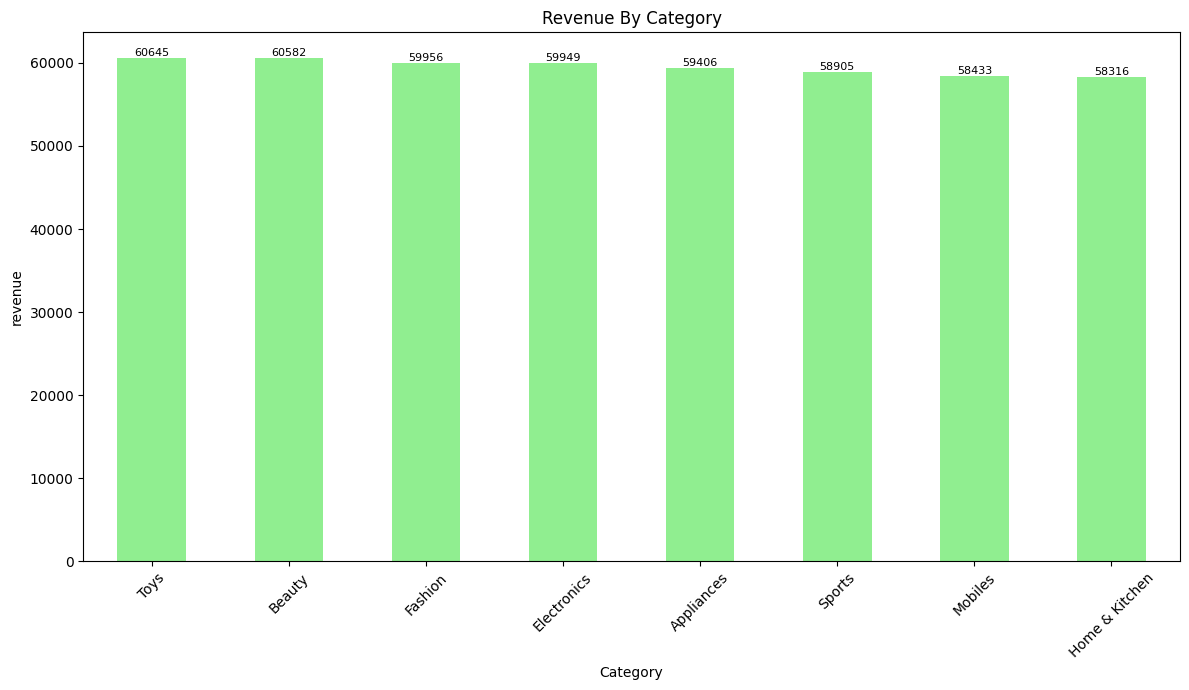

In [28]:
#EDA-Explorator Data Analysis

#Revenue BY Category

revenue_category=df.groupby('category')['revenue'].sum().div(10000000).round(2).sort_values(ascending=False)
df.groupby('category')['revenue'].sum()
#plot
plt.figure(figsize(12,7))
bx=revenue_category.plot(kind='bar',color='Lightgreen')
plt.title("Revenue By Category")
plt.xlabel('Category')
plt.ylabel('revenue')
plt.xticks(rotation=45)
# Add value labels
for container in bx.containers:
    bx.bar_label(container, fmt='%.0f', fontsize=8)
plt.tight_layout()
plt.show()

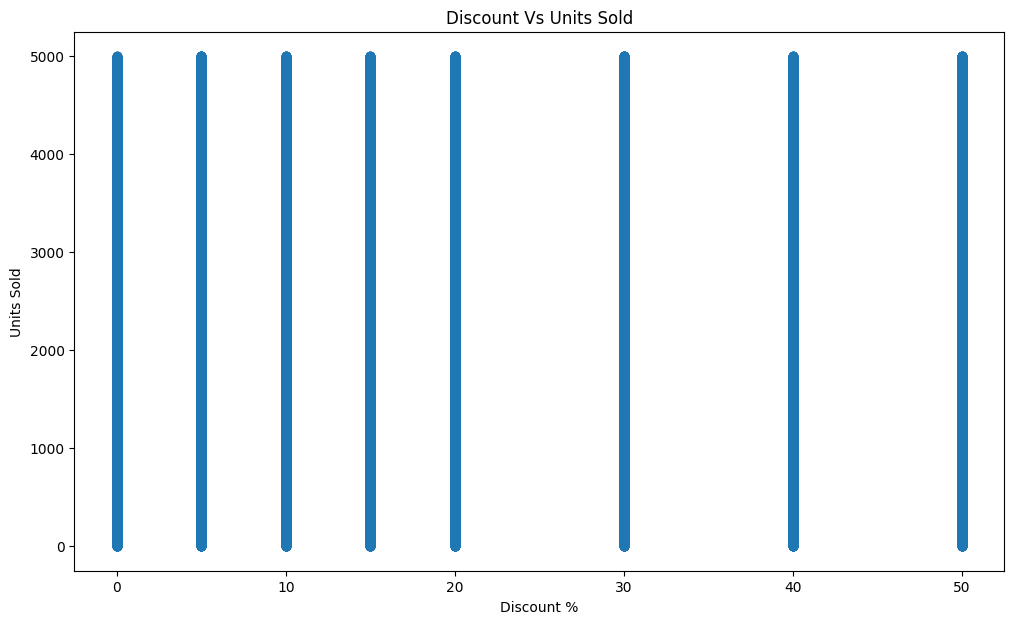

In [29]:
#Discount By Sales

df[['discount %','units_sold']].corr()
plt.scatter(df['discount %'],df['units_sold'])
plt.xlabel('Discount %')
plt.ylabel('Units Sold')
plt.title('Discount Vs Units Sold')
plt.show()


#  Electronics contribute highest revenue
#  Discounts positively impact sales up to a limit
#  Faster delivery improves ratings
#  Few top sellers generate majority revenue
#  Pune has the highest Revenue

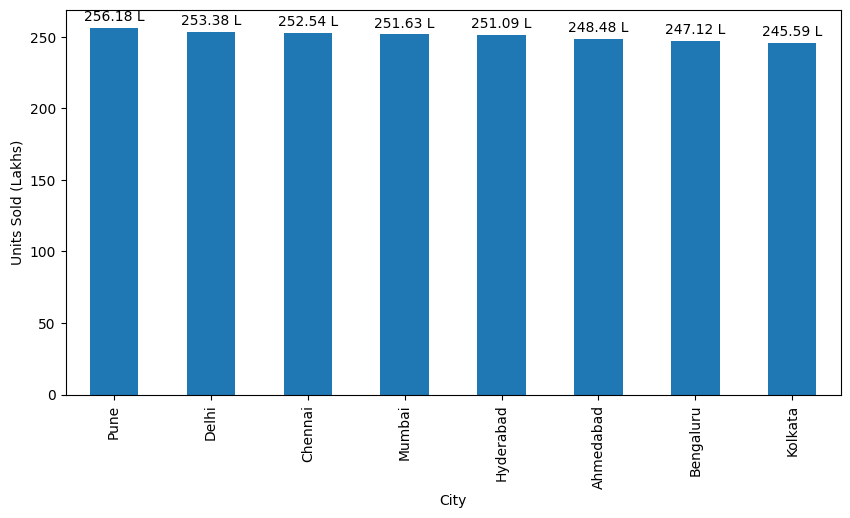

In [46]:
#CUSTOMER ANALYSIS QUESTIONS

# 1.customer Demotography
city_sales = (
    df.groupby('City')['units_sold']
      .sum()
      .div(100000)        # Convert to Lakhs
      .round(2)
      .sort_values(ascending=False)
)

ax = city_sales.plot(kind='bar', figsize=(10,5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f L', padding=3)

plt.ylabel("Units Sold (Lakhs)")
plt.show()
     

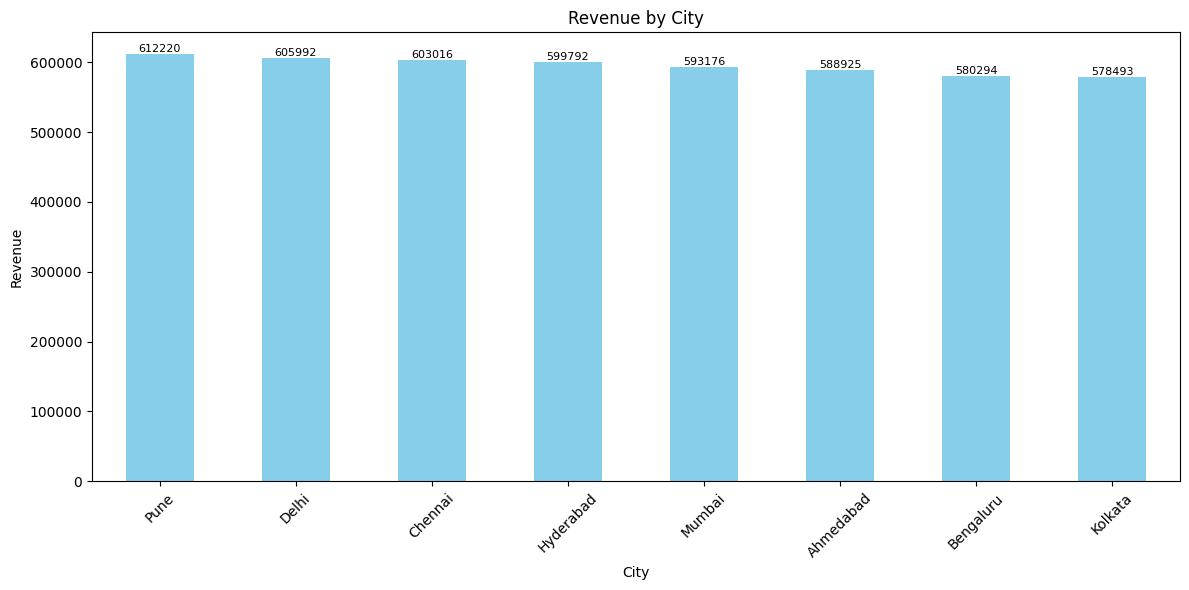

In [31]:
# 2.Revenue By City

df['revenue'] = df['final_price'] * df['units_sold']
city_revenue=df.groupby('City')['revenue'].sum().round(2).div(1000000).sort_values(ascending=False)
df.groupby('City')['revenue'].sum()
# Plot
plt.figure(figsize=(12,6))
ax = city_revenue.plot(kind='bar', color='skyblue')
plt.title('Revenue by City')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=8)
plt.tight_layout()
plt.show()

In [32]:
#Customer Purchasing Behavior

   #Preferred Payment Mode

c=df.groupby('payment_modes')['units_sold'].sum().round(2).div(1000)
print('perferred payment mode:',c)

perferred payment mode: payment_modes
CARD,Wallet     50348.210
COD,CARD        49991.256
COD,UPI,CARD    50016.289
UPI,CARD        50245.507
Name: units_sold, dtype: float64


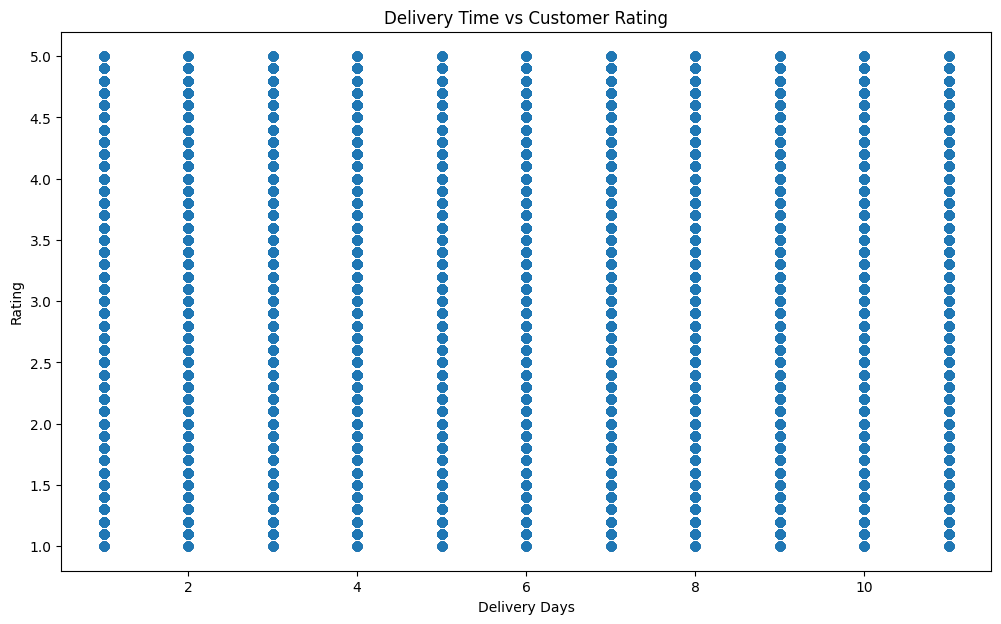

In [33]:
# Delivery Experience Impact on Customers

  #Delivery Days vs Rating

df.groupby('delivery_days')['rating'].mean()
plt.scatter(df['delivery_days'], df['rating'])
plt.xlabel("Delivery Days")
plt.ylabel("Rating")
plt.title("Delivery Time vs Customer Rating")
plt.show()

#Key Insight: Longer delivery → lower satisfaction.

In [34]:
#RETURNS AND CUSTOMER PERFERENCE

 #Returnable vs Non-Returnable

returnable=df.groupby('is_returnable') ['units_sold'].sum()
print(returnable)

# Key Insight: Customer prefer returnable products

is_returnable
False     39957883
True     160643379
Name: units_sold, dtype: int64


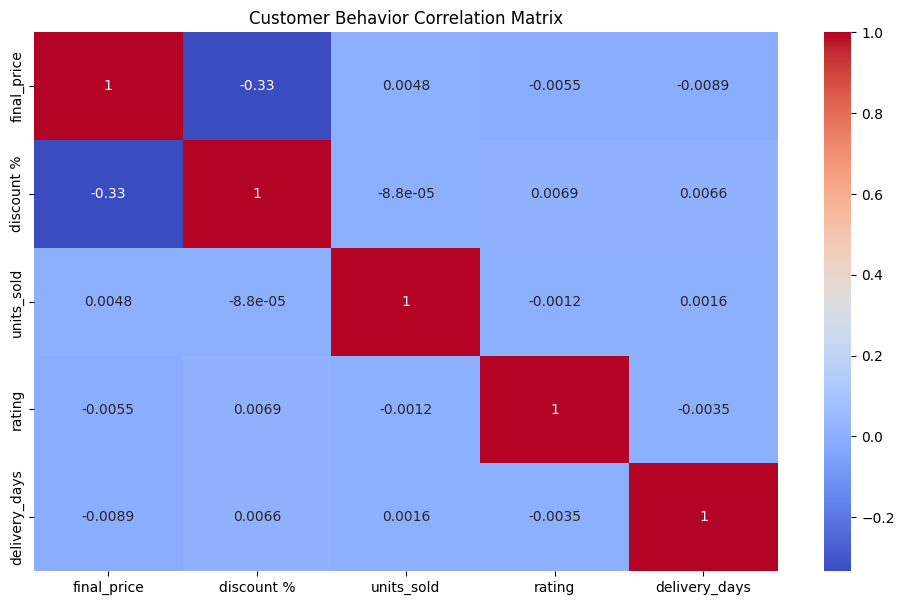

In [35]:
corr = df[['final_price','discount %','units_sold','rating','delivery_days']].corr()

#Correlation Heatmap

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Customer Behavior Correlation Matrix")
plt.show()

# Key Insights:
# Final Price and Discount have a moderate negative relationship (-0.33).
# All other variables have very weak or no linear correlation (values close to 0).
# Product price does not significantly affect sales volume.
# Discounts are not strongly associated with higher sales.
# Delivery time has little impact on ratings.
# Ratings are largely independent of price and discounts.


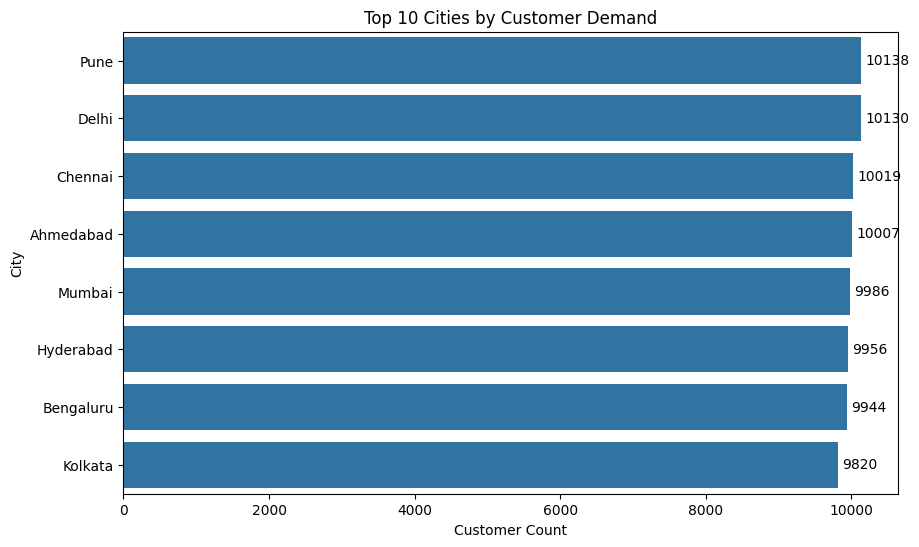

In [43]:
#City-wise Customer Demand

city_count = (
    df['City']
      .value_counts()
      .head(10)
      .reset_index()
)

city_count.columns = ['City', 'Customer_Count']

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=city_count,
    x='Customer_Count',
    y='City'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.title("Top 10 Cities by Customer Demand")
plt.xlabel("Customer Count")
plt.ylabel("City")

plt.show()

City
Hyderabad    5.97
Ahmedabad    5.99
Delhi        6.00
Chennai      6.01
Bengaluru    6.01
Kolkata      6.01
Mumbai       6.02
Pune         6.05
Name: delivery_days, dtype: float64


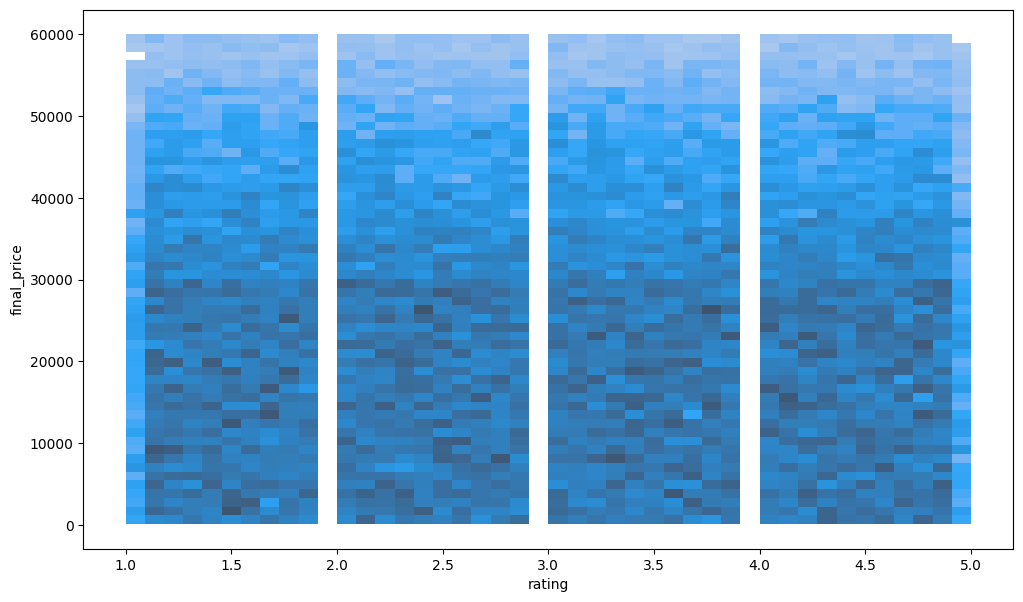

In [37]:
# City Vs Delivery Days

s=df.groupby('City')['delivery_days'].mean().sort_values().round(2)
print(s)
# Final Price VS Rating

sns.histplot(
    x='rating',
    y='final_price',
    data=df,
)
plt.show()

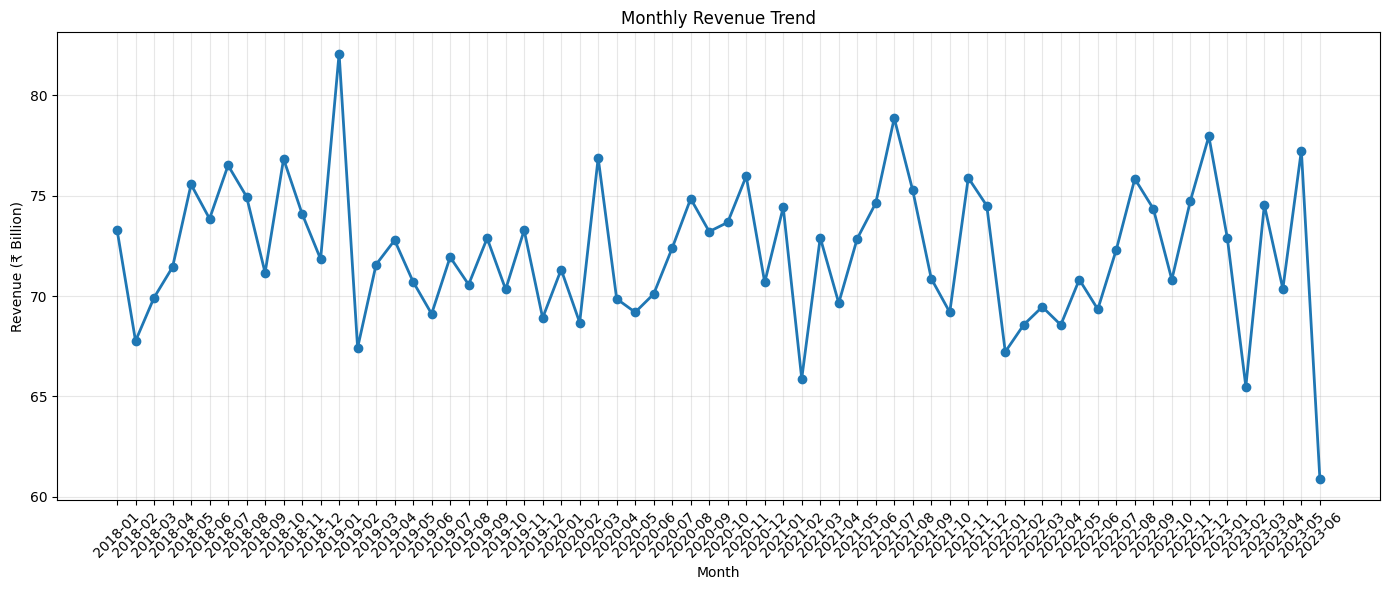

In [38]:
# How has revenue changed over time?

monthly = (
    df.groupby(df['listing_date'].dt.to_period('M'))['revenue']
      .sum()
      .reset_index()
)
monthly['listing_date'] = monthly['listing_date'].astype(str)
monthly['revenue_billion'] = (monthly['revenue'] / 1e9).round(2)

plt.figure(figsize=(14,6))
plt.plot(
    monthly['listing_date'],
    monthly['revenue_billion'],
    marker='o',
    linewidth=2
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Revenue (₹ Billion)")
plt.title("Monthly Revenue Trend")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:
#Which brands are driving revenue?
brand_rev =df.groupby('brand')['revenue'].sum().div(100000).round(2).sort_values(ascending=False)
print("brand_revenue",brand_rev)

brand_revenue brand
Nike         3237333.80
Adidas       3213176.29
Puma         3210515.65
Apple        3209929.31
Boat         3206117.76
Prestige     3196137.02
HP           3183559.97
Dell         3177141.25
Reebok       3171472.52
LG           3167956.32
Samsung      3151834.83
Redmi        3141371.75
Philips      3127237.73
Whirlpool    3123295.64
Sony         3101999.74
Name: revenue, dtype: float64


In [65]:
#Which cities have the fastest delivery?
df.groupby('City')['delivery_days'].mean()

City
Ahmedabad    5.988908
Bengaluru    6.008045
Chennai      6.005789
Delhi        5.997433
Hyderabad    5.967959
Kolkata      6.008656
Mumbai       6.018326
Pune         6.054843
Name: delivery_days, dtype: float64

In [41]:
# which seller are performing the best?
seller_rev = (
    df.groupby('seller')['revenue']
      .sum()
      .div(100000)      # Converting to Lakhs
      .round(2)
      .sort_values(ascending=False)
)

print(seller_rev)

seller
UrbanRetails    6043700.20
QuickShop       6014686.22
BestBuy         5964748.40
SuperMart       5953379.17
ValueKart       5948730.81
MegaStore       5937561.42
SmartDeals      5881427.06
RetailHub       5874846.30
Name: revenue, dtype: float64


In [61]:
#Which products receive the most reviews?
df.groupby('product_name')['review_count'].sum().head(10)

product_name
Adidas Edition 100     13738
Adidas Edition 101    158929
Adidas Edition 103     11892
Adidas Edition 104     10000
Adidas Edition 105     21250
Adidas Edition 106     41332
Adidas Edition 107     30777
Adidas Edition 108     29911
Adidas Edition 109     82639
Adidas Edition 11      48762
Name: review_count, dtype: int64